# <span style="color:#0b486b"> FIT3182: Assignment 2 (2026) </span>


# <span style="color:#0b486b">  Group Information</span>
---
Tutorial day and time: **Fri, 14:00 - 16:00**    <br/>

1st group member

Surname: **Lau**  <br/>
Firstname: **Brittany**    <br/>
Student ID: **(to be filled)**    <br/>
Email: **blau0015@student.monash.edu**    <br/>

2nd group member

Surname: **Tan**  <br/>
Firstname: **Zheng Heng**    <br/>
Student ID: **33982341**    <br/>
Email: **ztan0146@student.monash.edu**    <br/>

---

### Overview

This assignment assesses practical knowledge and implementation capability in MongoDB data modelling, event streaming, stateful processing, and analytical visualisation for a realistic traffic-monitoring scenario.
Students are required to design, implement, execute, and explain an end-to-end stream processing application using Apache Kafka, Apache Spark Structured Streaming, and MongoDB. The assignment focuses on volume, variety, and velocity in Big Data, with emphasis on data modelling, streaming correctness, state management, sink integration, code quality, and technical justification.
Students work in pairs for this assignment. Students can form their own pairs, but they should be from the same applied group. This is to streamline code demonstration in Week 12 during the applied session. Each pair can share the same code, output and documentation. However, each student should submit the assignment on Moodle. Additionally, the interview session is individual.

### Learning Outcomes

* Design appropriate MongoDB collections, indexes, and data retention policies for a stream analytics workload.
* Implement Kafka event producers and Spark Structured Streaming logic for joining multiple input streams.
* Apply state management and rule-based detection logic to identify violations from temporal event data.
* Integrate streaming outputs into MongoDB with clear consideration for correctness, efficiency, and idempotency.
* Develop clear technical visualisations and justify the operational value of analytical outputs.
* Communicate implementation decisions and defend design trade-offs during a technical demonstration and interview.

### Scenario Background

The assignment is framed around an Automated Awareness Safety System (AWAS)-style point-to-point traffic monitoring environment. Multiple roadside cameras record vehicle passages at fixed checkpoints. Camera events are streamed into a real-time processing application that must determine whether a vehicle has violated either the instantaneous speed limit at a camera or the average speed limit across a monitored road segment.
Students must design the storage model, simulate the incoming event streams, implement the online processing logic, and produce clear analytical outputs that support operational monitoring and enforcement use cases.

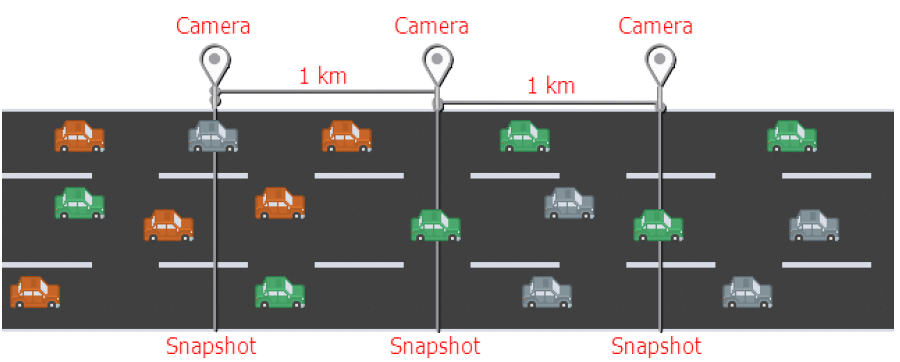

Figure 1. AWAS overview — Conceptual overview of data storage, streaming application, and visualisation components

### Dataset Context

This assignment uses an AWAS-inspired traffic monitoring scenario. The following dataset files are provided and should be used as the primary input source unless a task explicitly states otherwise.

| File               | Purpose                                                                 |
| ------------------ | ----------------------------------------------------------------------- |
| vehicle.csv        | Vehicle master data containing ownership and registration details.      |
| camera.csv         | Static camera metadata, including position and speed-limit definitions. |
| camera_event_A.csv | Camera event stream for Producer A.                                     |
| camera_event_B.csv | Camera event stream for Producer B.                                     |
| camera_event_C.csv | Camera event stream for Producer c.                                     |

Core fields expected in the event streams include event_id, batch_id, car_plate, camera_id, timestamp, and speed. Students may enrich the streamed payload with producer-specific metadata where appropriate to support traceability and debugging.

### Task 1.1: Collection Design

Related source:
[Google Document](https://docs.google.com/document/d/1qvWXG9UnDvegXUCI5_Rk4VVGLJ5p4IbJJxArHQKFi0Y/edit?tab=t.0)

---

#### Vehicle Collection

**Concise Description:**
* Stores vehicle registration details and owner information.
* Primary purpose: Owner identification and vehicle metadata for violations.
* Used in violation lookups and enforcement communications.

**Document Schema:**

```json
{
  "car_plate": {
    "type": "string",
    "description": "Vehicle registration plate (unique identifier)"
  },
  "owner_name": {
    "type": "string",
    "description": "Full name of vehicle owner"
  },
  "owner_addr": {
    "type": "string",
    "description": "Owner's residential address for enforcement notices"
  },
  "vehicle_type": {
    "type": "enum",
    "description": "Vehicle classification",
    "enum": ["Coupe", "SUV", "Sedan", "Van", "Truck", "Motorcycle"]
  },
  "registration_date": {
    "type": "datetime",
    "description": "Initial vehicle registration date"
  }
}
```

**Sample Document:**

```json
vehicle_example = {
  "car_plate": "FT 02",
  "owner_name": "Goh Mei Wei",
  "owner_addr": "943 Jalan Bukit Mawar, Kuala Lumpur",
  "vehicle_type": "Coupe",
  "registration_date": "2006-08-22T03:18:00"
}
```

**Indexes:**
```json
{ "car_plate": 1 }
```

A single-field ascending index is created on car_plate because it is the primary lookup key during stream processing. Every incoming violation event references a vehicle by its registration plate.

**Shard Key Strategy:**

* **Key:** `car_plate`
* **Type:** `hashed`
* **Justification:** To distribute vehicle related data evenly across shards.
The field car_plate is unique and has high cardinality (ideal for sharding). Furthermore, hashed keys avoid hotspots if some cars are more common.


**Data Retention Policy:**
Vehicle records are retained permanently because registration and ownership information may be required for historical tracking, investigation, and enforcement purposes. No automatic deletion policy is implemented.

---


#### Camera Collection

**Concise Description:**
* Stores fixed speed camera locations, configurations, and operational details.
* Primary purpose: Store camera metadata, speed limits, and geographic data.
* Used to validate violation events and retrieve limit thresholds.

**Document Schema:**

```json
{
    "camera_id": {
        "type": "integer",
        "description": "Unique camera identifier"
    },
    "latitude": {
        "type": "double",
        "description": "Geographic latitude coordinate"
    },
    "longitude": {
        "type": "double",
        "description": "Geographic longitude coordinate"
    },
    "position": {
        "type": "double",
        "description": "Road position marker or KM marker"
    },
    "speed_limit": {
        "type": "integer",
        "description": "Legal speed limit in km/h at this location"
    }
}
```

**Sample Document:**

```json
camera_example = {
    "camera_id": 1,
    "latitude": 2.157730731,
    "longitude": 102.6601002,
    "position": 152.5,
    "speed_limit": 110
}
```

**Indexes:**
```json
{ "camera_id": 1 }, { "location": "2dsphere" }
```
The ascending index on camera_id supports O(log(N)) lookups during stream processing, where camera metadata must be retrieved rapidly to evaluate each vehicle reading.

The 2dsphere index on location is included to support geospatial queries such as identifying violation hotspots within a radius, computing distances between camera pairs for average-speed segments, or rendering camera coverage on a map. Without this index, geospatial queries would degrade to full collection scans.


**Shard Key Strategy:**

Sharding is not applied to the cameras collection. The number of cameras in a typical deployment is small relative to the violation volume, and the collection is effectively read-only after initial setup. Distributing a small, static dataset across shards would introduce cross-shard routing latency for no gain.

**Data Retention Policy:**
Camera metadata is retained permanently because camera locations and speed-limit definitions are required for historical analysis and violation validation. No automatic deletion policy is implemented.

---

#### Violation Collection

**Justification of usage:**
To store records of flagged traffic violations, computed from matching camera events (Each document represents an instance of a speeding violation, either instantaneous or average speed). This is the core output of the streaming system, which is used for enforcement actions and analytics

**Document Schema:**

```json
{
  "car_plate": {
    "type": "string",
    "description": "Vehicle registration plate (unique identifier)"
  },
  "violation_date": {
    "type": "date",
    "description": "Specific date when the violations occurred, used for grouping"
  },
  "violations": {
    "type": "array",
    "description": "A collection of all detected speeding events for this vehicle on this date",
    "items": {
      "violation_type": {
        "type": "enum",
        "description": "The category of violation: 'speed' (instantaneous) or 'average_speed' (point-to-point)"
      },
      "speed_limit": {
        "type": "float",
        "description": "The legal speed limit enforced at the camera location(s)"
      },
      "event_details": {
        "type": "object",
        "description": "A container for telemetry data that changes based on the violation_type",
        "properties": {
          "camera_id": {
            "type": "integer",
            "description": "Unique ID of the camera (used for 'speed' type)"
          },
          "timestamp": {
            "type": "datetime",
            "description": "Exact time the vehicle passed the camera (used for 'speed' type)"
          },
          "speed": {
            "type": "float",
            "description": "The recorded instantaneous speed in km/h (used for 'speed' type)"
          },
          "camera_id_start": {
            "type": "integer",
            "description": "The ID of the entry camera (used for 'average_speed' type)"
          },
          "camera_id_end": {
            "type": "integer",
            "description": "The ID of the exit camera (used for 'average_speed' type)"
          },
          "timestamp_start": {
            "type": "datetime",
            "description": "The entry timestamp for the segment (used for 'average_speed' type)"
          },
          "timestamp_end": {
            "type": "datetime",
            "description": "The exit timestamp for the segment (used for 'average_speed' type)"
          },
          "avg_speed": {
            "type": "float",
            "description": "The computed average speed over the known distance (used for 'average_speed' type)"
          }
        }
      }
    }
  }
}
```

### Task 1.2 Collection Relationship (1 mark)

The database design consists of three primary collections: vehicles, cameras, and violations. The collections are designed to balance efficient streaming writes, analytical query performance, reduced data duplication, and consistency of reference data.

#### Referencing for static metadata (vehicles and cameras)

Both vehicles and cameras contain reference data that is written once and updated rarely. Rather than duplicating this information inside every violation document, the schema stores only the foreign key (car_plate for vehicle ownership and camera_id for camera metadata) within the violations collection. This referencing strategy is justified on three grounds.

First, it eliminates redundant duplication. If owner contact details or a camera's speed-limit assignment were embedded in each violation, a single update such as a camera reconfiguration would require a costly bulk write across every affected violation document. Referencing confines such updates to a single authoritative record.

Second, it preserves data consistency. With embedding, concurrent updates to the same vehicle or camera record across multiple violation documents would require distributed transactions or risk divergence. Referencing avoids this problem entirely by maintaining a single source of truth in the vehicles and cameras collections.

Third, the join cost is acceptable given the access pattern. Vehicle and camera metadata is typically resolved at query time. For example, when generating an enforcement report rather than during high-frequency streaming writes. MongoDB's $lookup aggregation pipeline handles this efficiently for batch analytical queries, and the indexed lookup on car_plate and camera_id ensures that the additional round-trip cost remains bounded.

#### Embedding for violation events

Within the violations collection, individual violation events are embedded as an array inside a single daily document per vehicle, rather than stored as separate top-level documents. This design decision is driven by write pattern, query locality, and document growth characteristics.

From a write perspective, embedding supports efficient upsert operations during stream processing. When a new violation is detected, a single findOneAndUpdate with $push and upsert=True appends the event to the existing daily document. The alternative, storing each violation as an independent document, would generate a far larger number of small writes, increase index contention, and complicate the retrieval of all violations for a vehicle on a given date.

From a read perspective, embedding improves locality. Violations for the same vehicle on the same day are stored contiguously on disk, meaning a single document fetch retrieves the entire day's offence history without requiring multiple lookups or aggregation joins. This directly benefits operational dashboards and enforcement workflows that commonly query violations by vehicle and date.

The principal risk of embedding (unbounded document growth) is mitigated by the daily grouping boundary. Because each document is scoped to a single calendar day, the maximum number of embedded violations per document is constrained by the finite number of camera readings a vehicle can generate in 24 hours. MongoDB's 16 MB document size limit is therefore unlikely to be reached in practice.

#### Design trade-off summary

The schema's referencing strategy accepts a bounded join cost in return for a single authoritative source for vehicle and camera metadata, eliminating the consistency risks that bulk duplication would introduce. The sole exception — duplicating speed_limit inside each violation document — is intentional and legally motivated. Speed limits must be recorded as they were at the time of detection; retrospective changes to camera configuration should have no bearing on previously issued offences. This duplication is therefore a feature of the audit trail, not a deficiency in the schema.

